In [13]:
import pandas as pd

# Train- und Testdaten laden
train_df = pd.read_parquet('train_block_1.parquet')
test_df  = pd.read_parquet('test_block_1.parquet')

# Labels umwandeln
train_df['Label'] = train_df['Label'].replace({'benign': 0, 'attack': 1})
test_df['Label']  = test_df['Label'].replace({'benign': 0, 'attack': 1})

# Features und Zielvariablen festlegen
X_train = train_df.drop(['Label', 'timestamp', 'attack'], axis=1)
y_train = train_df['Label']
X_test  = test_df.drop(['Label', 'timestamp', 'attack'], axis=1)
y_test  = test_df['Label']


/tmp/ipykernel_161375/4074336563.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Label'] = train_df['Label'].replace({'benign': 0, 'attack': 1})
/tmp/ipykernel_161375/4074336563.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Label']  = test_df['Label'].replace({'benign': 0, 'attack': 1})


In [12]:
import pandas as pd

# Daten laden
train_df = pd.read_parquet('train_block_1.parquet')
test_df  = pd.read_parquet('test_block_1.parquet')

# Labels umwandeln
train_df['Label'] = train_df['Label'].replace({'benign': 0, 'attack': 1})
test_df['Label']  = test_df['Label'].replace({'benign': 0, 'attack': 1})

# Erlaubte Features definieren (nur diese 20)
allowed_features = [
    'node-stores',
    'cpu-cycles',
    'block_block_bio_queue',
    'jbd2_jbd2_commit_flushing',
    'syscalls_sys_exit_pipe2',
    'st_spec',
    'dTLB-load-misses',
    'sched_sched_waking',
    'bus_access',
    'br_immed_spec',
    'bus_access_periph',
    'l1d_cache_rd',
    'l1d_cache_wb',
    'node-loads',
    'l2d_cache_wb',
    'l1d_tlb_refill_rd',
    'context-switches',
    'rc_ld_spec',
    'exc_return',
    'br_mis_pred'
]

# Nur diese Features auswählen
X_train = train_df[allowed_features]
X_test = test_df[allowed_features]

y_train = train_df['Label']
y_test = test_df['Label']

# Modell trainieren
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


/tmp/ipykernel_161375/3213001655.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Label'] = train_df['Label'].replace({'benign': 0, 'attack': 1})
/tmp/ipykernel_161375/3213001655.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Label']  = test_df['Label'].replace({'benign': 0, 'attack': 1})


DecisionTreeClassifier(random_state=42)

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

[[ 106  201]
 [  31 1699]]


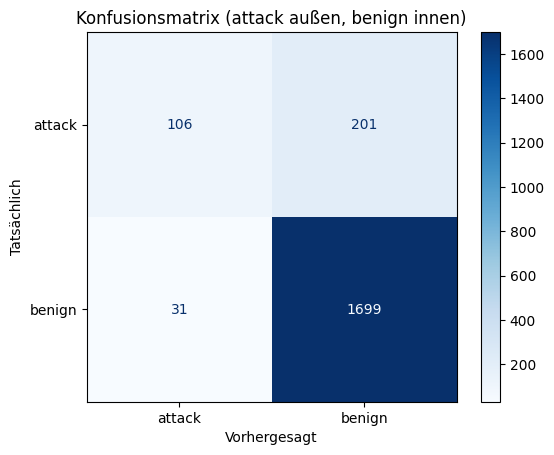

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Schritt 1: Vorhersagen berechnen
y_pred = model.predict(X_test)

# Reihenfolge: zuerst 'attack' (1), dann 'benign' (0)
labels = [1, 0]

# Neue Konfusionsmatrix mit expliziten Labels
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

# Anzeige mit angepasster Beschriftung
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['attack', 'benign'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Konfusionsmatrix (attack außen, benign innen)')
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.show()


In [16]:
# Vorhersage
y_pred = model.predict(X_test)
# Test-Daten nochmals laden, falls nicht vorhanden
test_df = pd.read_parquet('test_block_1.parquet')

# Falls noch nicht umgewandelt:
test_df['Label'] = test_df['Label'].replace({'benign': 0, 'attack': 1})

# Indizes suchen, wo es tatsächlich ein Angriff (1) war, aber das Modell benign (0) erkannt hat
mask = (test_df['Label'] == 1) & (y_pred == 0)
fehlklassifizierte = test_df[mask]


/tmp/ipykernel_161375/4237760541.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Label'] = test_df['Label'].replace({'benign': 0, 'attack': 1})


In [17]:
# Alle falsch als benign erkannten Angriffe und ihr Typ
print(fehlklassifizierte[["attack"]].value_counts())


attack          
osfingerprinting    56
aggressivescan      55
portscan            45
slowloris           42
synonymousflood      3
Name: count, dtype: int64


In [18]:
# Die Wichtigkeiten und Namen holen
importances = model.feature_importances_
feature_names = X_train.columns

# Als Series sortieren
feat_imp = pd.Series(importances, index=feature_names)
top_features = feat_imp.sort_values(ascending=False).head(20)

In [19]:
print(top_features)


node-stores                  0.471010
cpu-cycles                   0.185045
block_block_bio_queue        0.113598
jbd2_jbd2_commit_flushing    0.051249
syscalls_sys_exit_pipe2      0.030773
st_spec                      0.023672
dTLB-load-misses             0.019886
sched_sched_waking           0.008935
bus_access                   0.008918
br_immed_spec                0.006685
bus_access_periph            0.006639
l1d_cache_rd                 0.003959
l1d_cache_wb                 0.003674
node-loads                   0.003658
l2d_cache_wb                 0.003627
l1d_tlb_refill_rd            0.003618
context-switches             0.003512
rc_ld_spec                   0.003362
exc_return                   0.003345
br_mis_pred                  0.003336
dtype: float64


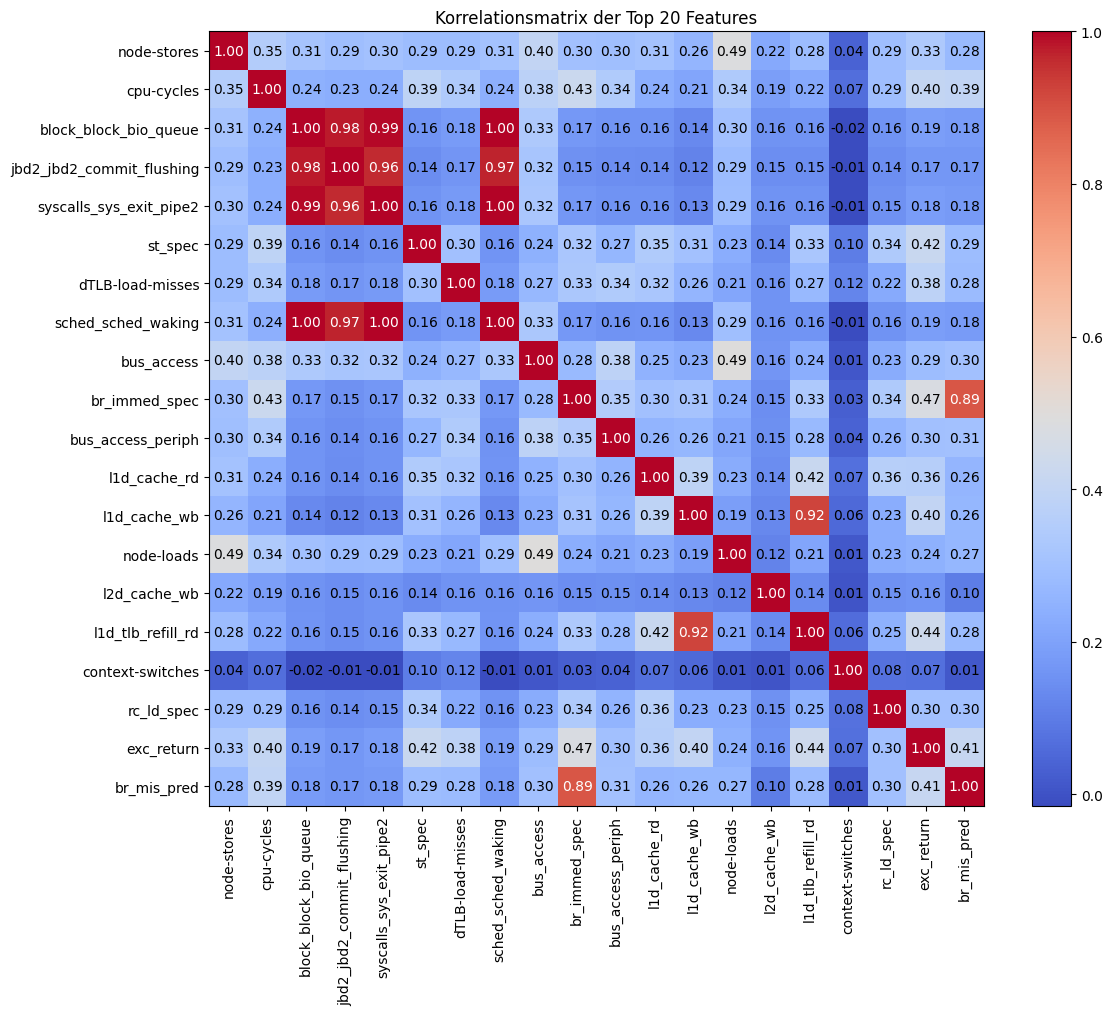

In [27]:

import matplotlib.pyplot as plt
import numpy as np

X_top20 = X_train[top20_names]
corr_matrix = X_top20.corr()


plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Korrelationsmatrix der Top 20 Features")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Korrelationswerte in Matrix drucken
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        wert = corr_matrix.iloc[i, j]
        # Weiße Schrift bei starkem Zusammenhang für bessere Lesbarkeit
        farbe = 'white' if abs(wert) > 0.5 else 'black'
        plt.text(j, i, f'{wert:.2f}', ha='center', va='center', color=farbe)

plt.tight_layout()
plt.show()


In [7]:
import joblib

# Modell speichern
joblib.dump(model, 'decision_tree_model.joblib')


['decision_tree_model.joblib']